In [1]:
import joblib             as jlb
import matplotlib.pyplot  as plt
import pandas             as pd
import warnings
warnings.filterwarnings('ignore') # tắt những cảnh báo

from collections           import Counter
from sklearn.cluster       import DBSCAN
from Dataprepare.data_processing import D

Tiền xử lý dữ liệu

In [2]:
features=[
 'balance',
 'purchases',
 'cash_advance'
]
data=D[features].copy()
print(data.shape)
print(data.tail(1))

(1898, 3)
       balance  purchases  cash_advance
1897  0.337792  -1.836079      0.458427


In [3]:
##------------------------------------------------------------------------------
## Xây dựng mô hình DBSCAN
##------------------------------------------------------------------------------
## eps        : bán kính lân cận (neighborhood radius)
## min_samples: số điểm tối thiểu trong lân cận để tạo thành core point
##
## Nhãn cluster = -1 → điểm NHIỄU (noise/outlier), không thuộc cụm nào
##------------------------------------------------------------------------------
model = DBSCAN(eps=0.5, min_samples=10)
model.fit(data)  # xây dựng mô hình

,eps,0.5
,min_samples,10
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [4]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(model,'../customer_clustering/Output/clarans.mdl')

['../customer_clustering/Output/clarans.mdl']

In [5]:
## Khai thác mô hình đã được xây dựng
model = jlb.load('../customer_clustering/Output/clarans.mdl')

In [7]:
## Kết quả gom cụm khách hàng
data['cluster'] = model.labels_
print(data[['balance','purchases','cluster']].head())

n_clusters = len(set(model.labels_)) - (1 if -1 in model.labels_ else 0)
n_noise    = list(model.labels_).count(-1)

print(f'\nSố clusters tìm được  : {n_clusters}')
print(f'Số điểm nhiễu (noise): {n_noise}')
print('\nKích thước các clusters (bao gồm noise = -1):', Counter(model.labels_))

    balance  purchases  cluster
0 -1.594479  -0.275098        0
1  0.746068  -1.836079        1
2  0.611419   0.436726        0
3  0.009768  -0.868018        0
4  0.438191   0.622723        0

Số clusters tìm được  : 3
Số điểm nhiễu (noise): 30

Kích thước các clusters (bao gồm noise = -1): Counter({np.int64(0): 976, np.int64(2): 533, np.int64(1): 359, np.int64(-1): 30})


In [8]:
for eps in [0.2, 0.3, 0.5, 0.8, 1.0]:
    m          = DBSCAN(eps = eps, min_samples = 10).fit(data)
    n_clusters = len(set(m.labels_)) - (1 if -1 in m.labels_ else 0)
    n_noise    = list(m.labels_).count(-1)
    print(f'eps={eps} → clusters: {n_clusters}, noise: {n_noise}')

eps=0.2 → clusters: 4, noise: 419
eps=0.3 → clusters: 3, noise: 146
eps=0.5 → clusters: 3, noise: 30
eps=0.8 → clusters: 4, noise: 20
eps=1.0 → clusters: 4, noise: 19


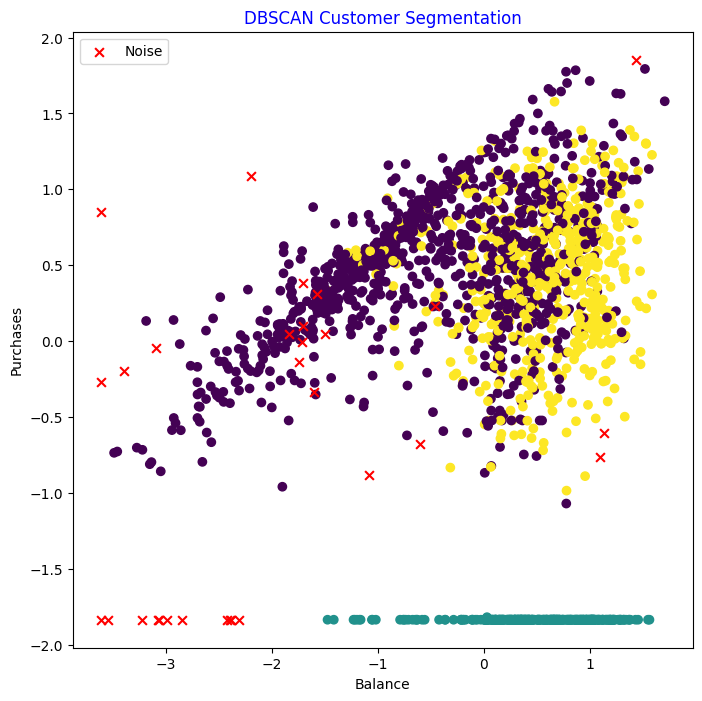

In [9]:
noise    = data[data.cluster == -1]
clusters = data[data.cluster != -1]

plt.figure(figsize=(8, 8))
plt.scatter(clusters.balance, clusters['purchases'], c=clusters.cluster)
plt.scatter(noise.balance, noise['purchases'], c='red', marker='x', s=40, label='Noise', zorder=5)
plt.xlabel('Balance')
plt.ylabel('Purchases')
plt.title('DBSCAN Customer Segmentation', color='blue')
plt.legend()
plt.show()